In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("injection_molding_predictive_maintenance.csv")
print("Shape:", df.shape)

Shape: (40000, 54)


In [3]:
print("\nDtypes:\n", df.dtypes.value_counts())


Dtypes:
 float64    37
int64      13
object      4
Name: count, dtype: int64


In [4]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
mold_id                     0
mold_name                   0
timestamp                   0
material_name               0
machine_tonnage             0
cycle_number                0
hopper_temp                 0
nozzle_temp                 0
H1                          0
H2                          0
H3                          0
mold_core_temp              0
mold_cavity_temp            0
inj_speed1                  0
inj_speed2                  0
inj_speed3                  0
max_inj_pressure            0
normal_inj_pressure         0
vp_transition               0
inj_time_limit              0
inj_time_actual             0
holding_pressure            0
total_hold_time             0
screw_rpm                   0
back_pressure               0
decompression_speed         0
decompression_distance      0
cushion_size                0
cushion_position            0
clamp_force                 0
mold_close_speed            0
mold_protection_pressure    0
ejection_str

In [5]:
print("\nExact duplicate rows:", df.duplicated().sum())
df.head()


Exact duplicate rows: 0


,mold_id,mold_name,timestamp,material_name,machine_tonnage,cycle_number,hopper_temp,nozzle_temp,H1,H2,...,total_cycle_time,Hopper_State,Barrel_Heater_State,Screw_State,Injection_Unit_State,Hydraulic_System_State,Clamp_Unit_State,Mold_State,Cooling_System_State,Ejector_System_State
0,TL-2026-ABS-0892,Smart Router Enclosure (Top Cover) - 2 Cavity,00:00.0,"ABS (Flame Retardant, Medium Flow)",180,1,45.4,230.1,224.5,214.6,...,24.304,0,0,0,0,0,0,0,0,0
1,TL-2026-ABS-0892,Smart Router Enclosure (Top Cover) - 2 Cavity,00:24.3,"ABS (Flame Retardant, Medium Flow)",180,2,45.0,230.4,226.5,216.0,...,24.360,0,0,0,0,0,0,0,0,0
2,TL-2026-ABS-0892,Smart Router Enclosure (Top Cover) - 2 Cavity,00:48.7,"ABS (Flame Retardant, Medium Flow)",180,3,45.7,229.9,225.4,215.5,...,24.418,0,0,0,0,0,0,0,0,0
3,TL-2026-ABS-0892,Smart Router Enclosure (Top Cover) - 2 Cavity,01:13.1,"ABS (Flame Retardant, Medium Flow)",180,4,45.3,229.4,225.9,215.1,...,24.522,0,0,0,0,0,0,0,0,0
4,TL-2026-ABS-0892,Smart Router Enclosure (Top Cover) - 2 Cavity,01:37.6,"ABS (Flame Retardant, Medium Flow)",180,5,45.2,230.4,225.7,215.1,...,24.292,0,0,0,0,0,0,0,0,0


In [ ]:
TARGET_MAP = {
    "Heater": "Barrel_Heater_State",
    "Hydraulic": "Hydraulic_System_State",
    "Screw": "Screw_State",
    "Clamp": "Clamp_Unit_State",
    "Hopper": "Hopper_State",
    "InjectionUnit": "Injection_Unit_State",
    "Mold": "Mold_State",
    "Cooling": "Cooling_System_State",
    "Ejector": "Ejector_System_State",
}

STATE_LABELS = {
    0: "Healthy",
    1: "Degrading",
    2: "Failure Near",
    3: "Failed",
}

print("Targets modeled:")
for name, col in TARGET_MAP.items():
    print(f"- {name:13s} -> {col}")

#rows belong to each class for every target column
print("\nTarget column class counts (raw):\n")
for name, col in TARGET_MAP.items():
    counts = df[col].value_counts().sort_index()
    pct = (counts / len(df) * 100).round(2)
    print(f"{name} -> {col}")
    for k in counts.index:
        print(f"  {k}: count={counts[k]}, pct={pct[k]}%")
    print()

Targets modeled:
- Heater        -> Barrel_Heater_State
- Hydraulic     -> Hydraulic_System_State
- Screw         -> Screw_State
- Clamp         -> Clamp_Unit_State
- Hopper        -> Hopper_State
- InjectionUnit -> Injection_Unit_State
- Mold          -> Mold_State
- Cooling       -> Cooling_System_State
- Ejector       -> Ejector_System_State

Target column class counts (raw):

Heater -> Barrel_Heater_State
  0: count=34692, pct=86.73%
  1: count=2859, pct=7.15%
  2: count=1715, pct=4.29%
  3: count=734, pct=1.84%

Hydraulic -> Hydraulic_System_State
  0: count=32908, pct=82.27%
  1: count=3455, pct=8.64%
  2: count=2654, pct=6.64%
  3: count=983, pct=2.46%

Screw -> Screw_State
  0: count=33493, pct=83.73%
  1: count=3509, pct=8.77%
  2: count=2112, pct=5.28%
  3: count=886, pct=2.22%

Clamp -> Clamp_Unit_State
  0: count=35846, pct=89.62%
  1: count=2158, pct=5.4%
  2: count=1394, pct=3.48%
  3: count=602, pct=1.5%

Hopper -> Hopper_State
  0: count=33919, pct=84.8%
  1: count=3762

In [ ]:
def parse_mmss(ts):
    #Parse 'MM:SS.s' style into seconds; return NaN if malformed.
    try:
        if isinstance(ts, str) and ":" in ts:
            mm, ss = ts.split(":")
        else:
            mm, ss = str(ts)[:-4], str(ts)[-4:]
        return int(mm) * 60 + float(ss)
    except Exception:
        return np.nan

# Handle timestamp if present
if "timestamp" in df.columns:
    df["timestamp_parsed_sec"] = df["timestamp"].apply(parse_mmss)
    malformed = df["timestamp_parsed_sec"].isna().sum()
    print("Malformed timestamp rows:", malformed)
    # Drop original timestamp if you don't want to use it later
    df = df.drop(columns=["timestamp"])

# Numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Replace infinities
n_inf = np.isinf(df[numeric_cols].values).sum()
print("Infinite values found:", n_inf)
if n_inf > 0:
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Check missing
n_missing = df.isna().sum().sum()
print("Total missing values:", n_missing)

Malformed timestamp rows: 0
Infinite values found: 0
Total missing values: 0


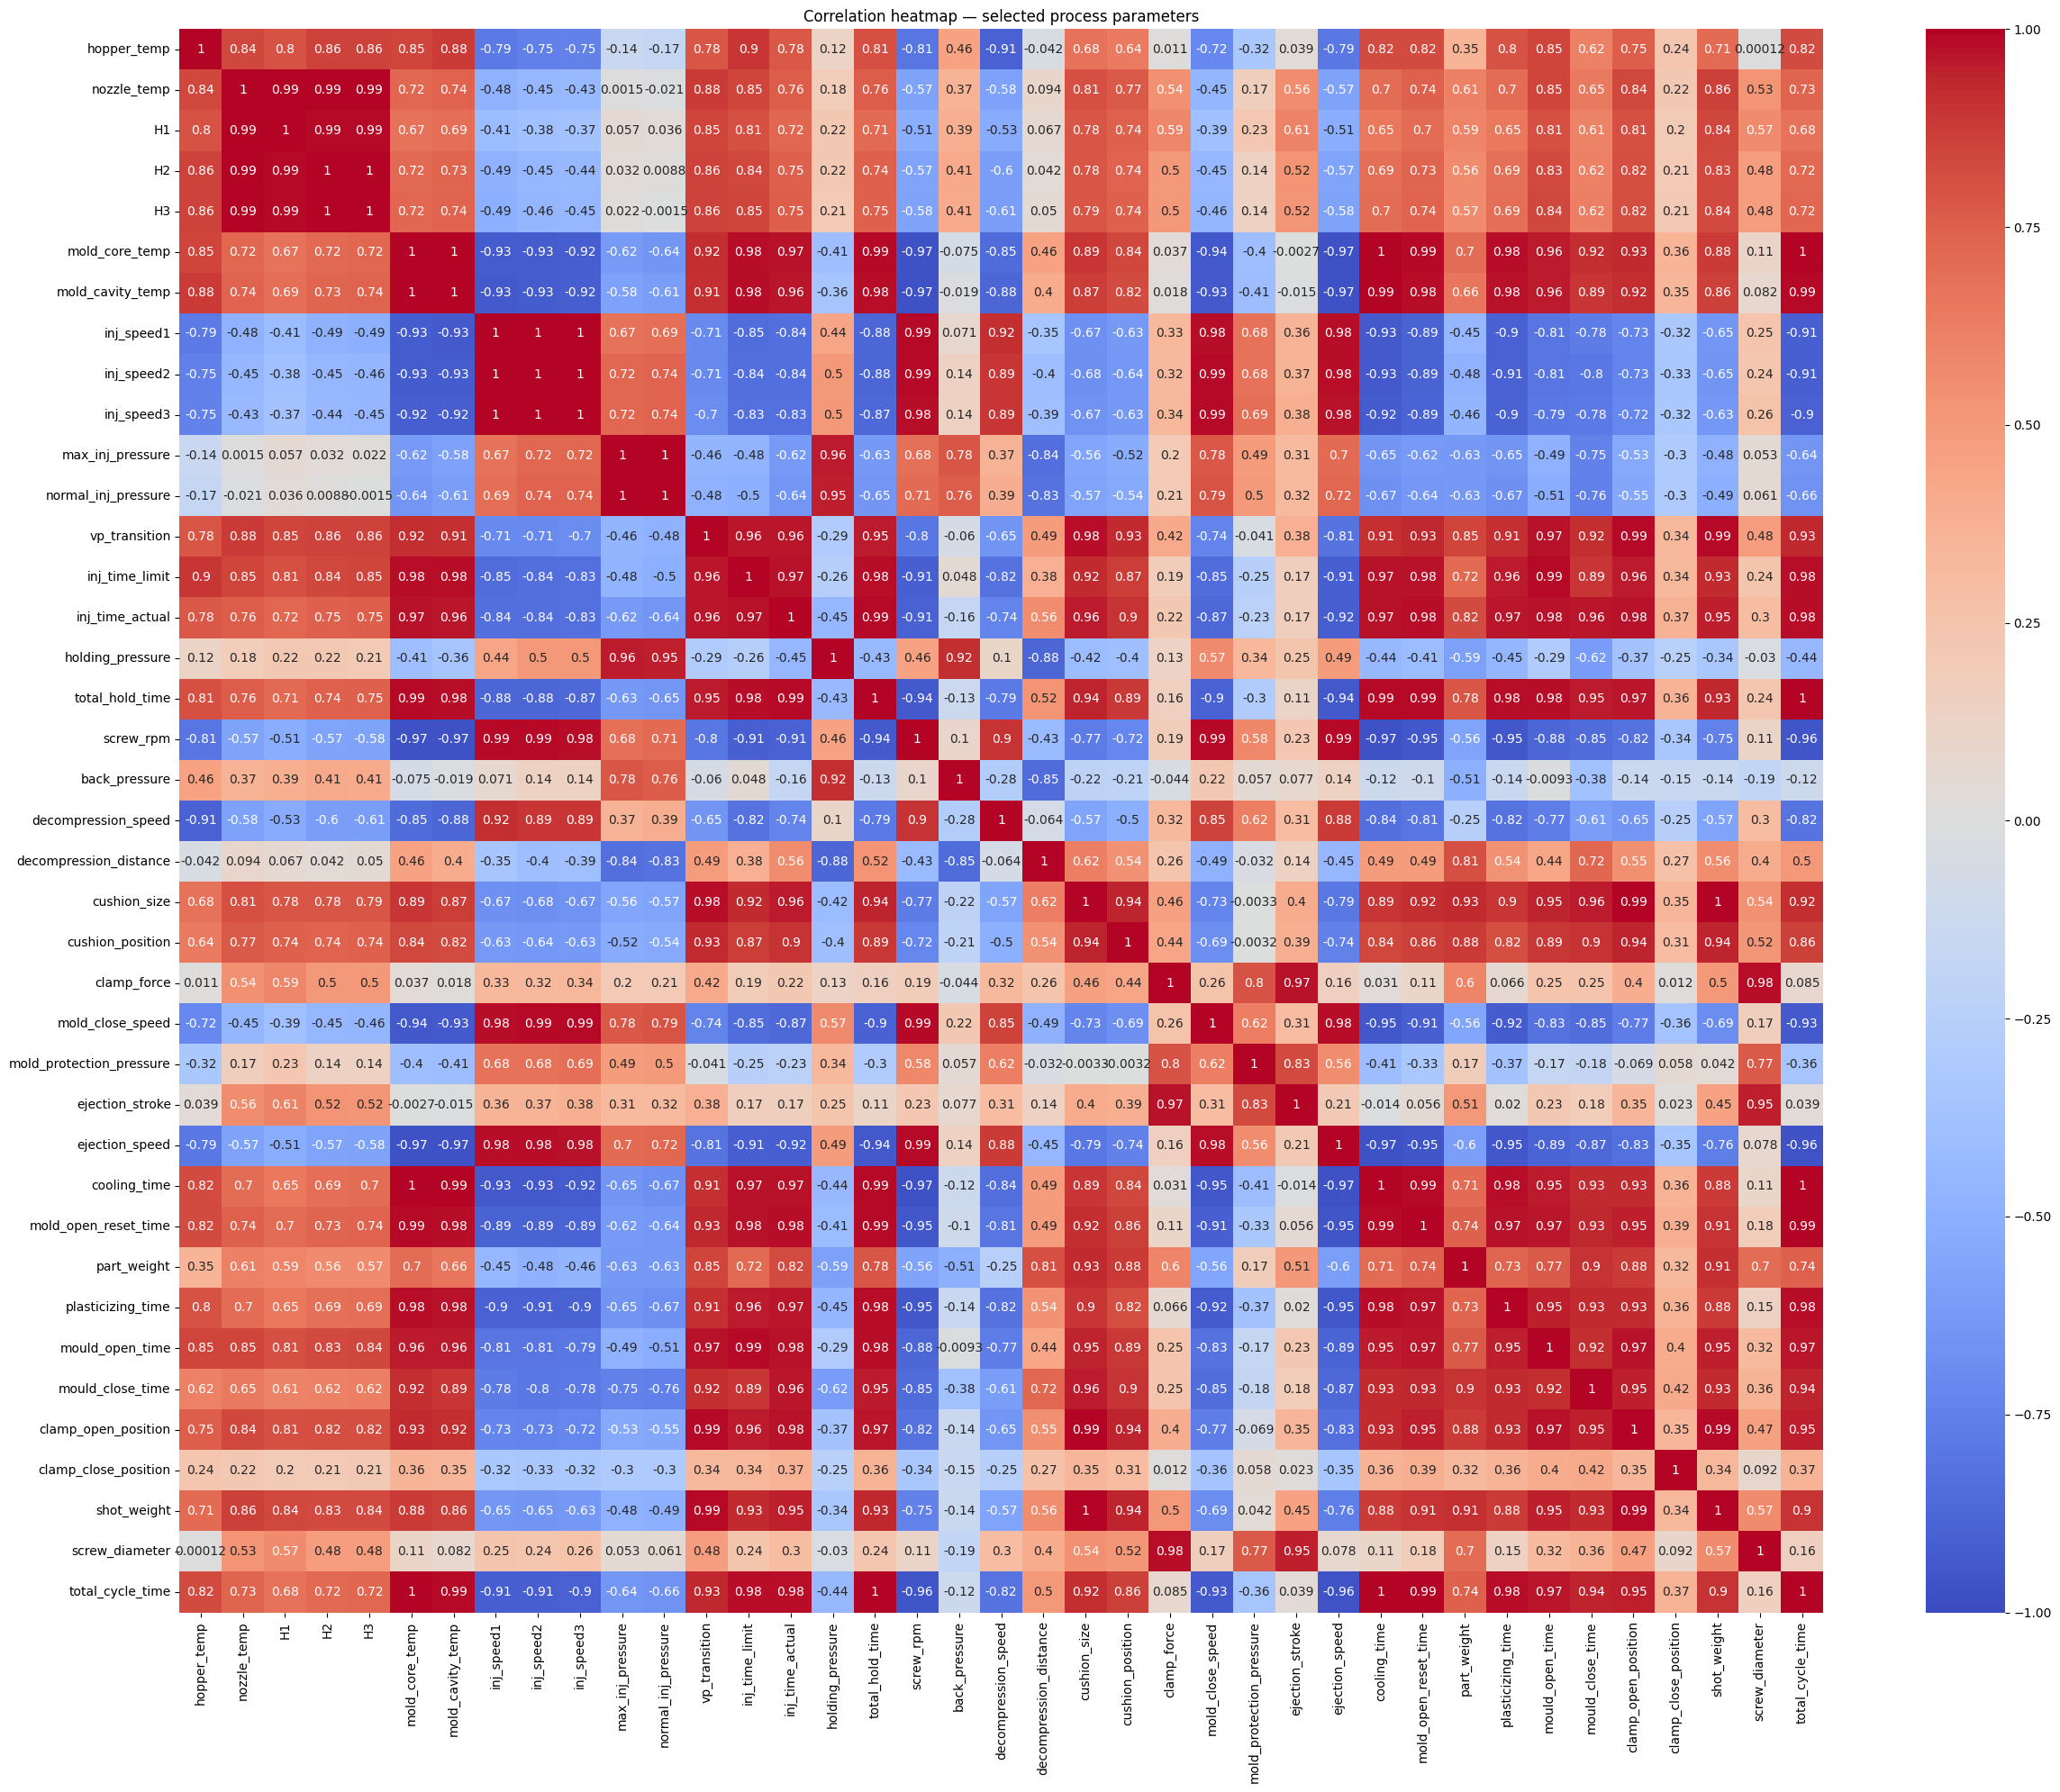

In [ ]:
#correlation heatmap 
plt.figure(figsize=(25, 20))
sns.heatmap(df.iloc[:, 5:44].corr(),annot=True,cmap="coolwarm",center=0,vmin=-1,vmax=1)
plt.title("Correlation heatmap — selected process parameters")
plt.tight_layout()
plt.show()
plt.close()

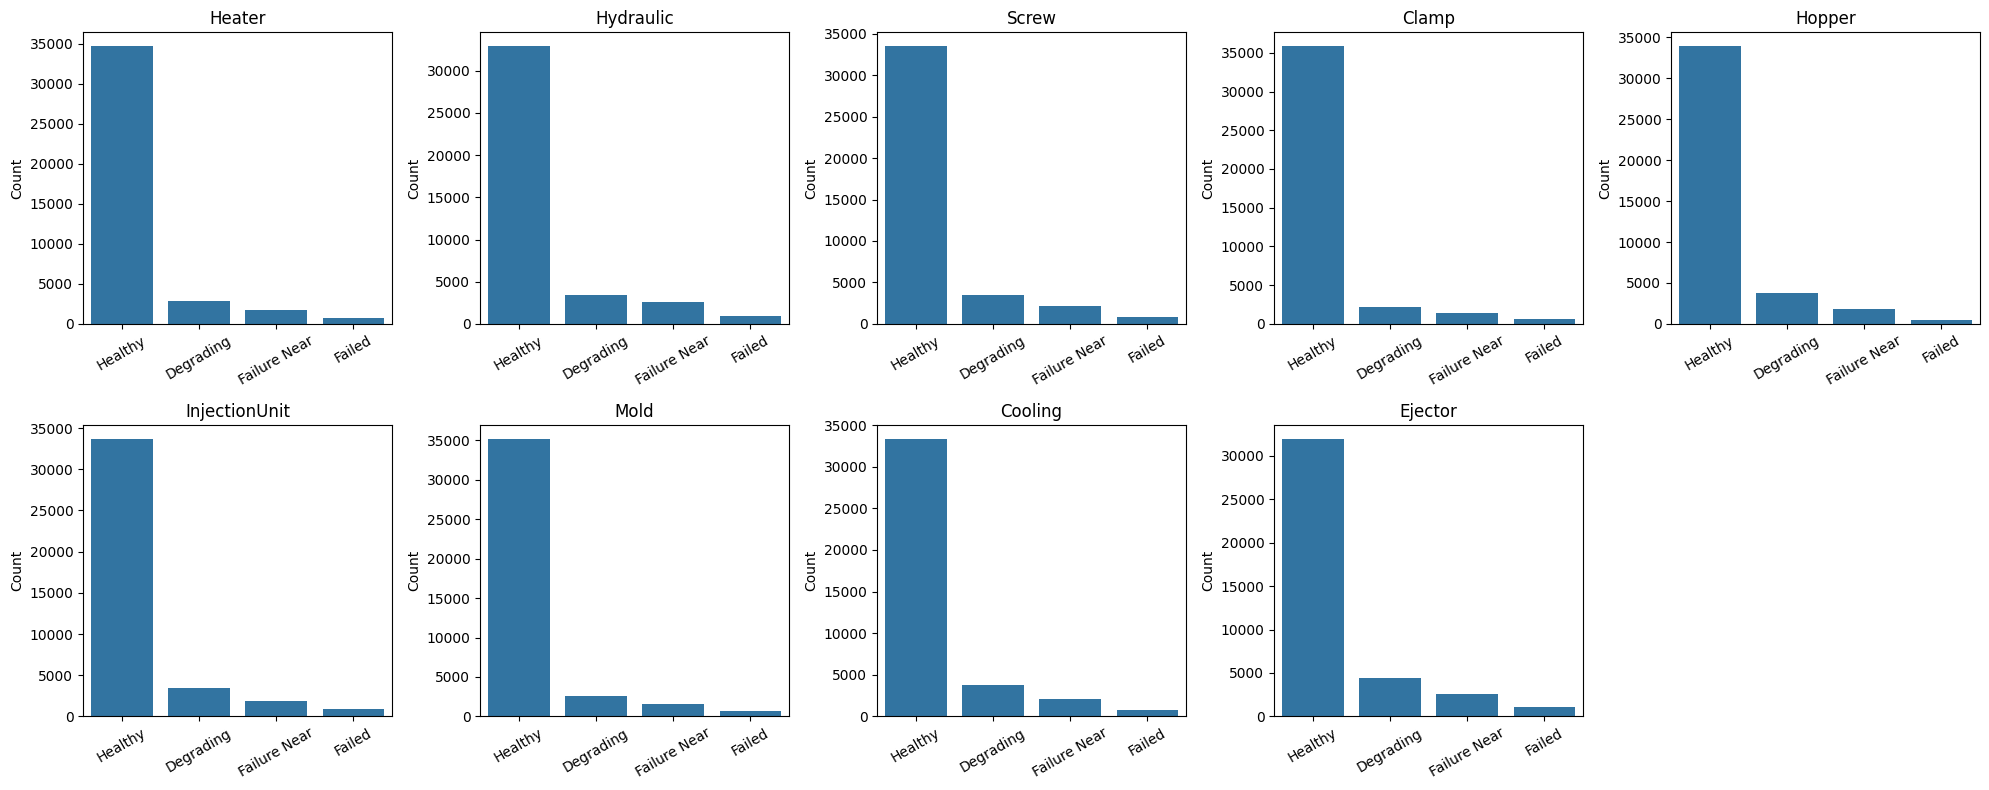

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for i, (name, col) in enumerate(TARGET_MAP.items()):
    counts = df[col].value_counts().sort_index()

    sns.barplot(x=[STATE_LABELS.get(x, str(x)) for x in counts.index],y=counts.values,ax=axes[i])

    axes[i].set_title(name)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)

axes[-1].axis("off")

plt.tight_layout()
plt.show()